<a href="https://colab.research.google.com/github/chrishg23-jpg/Community-Development-Framework/blob/main/Lattice001.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

/tmp/ipykernel_897/4157700520.py:96: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


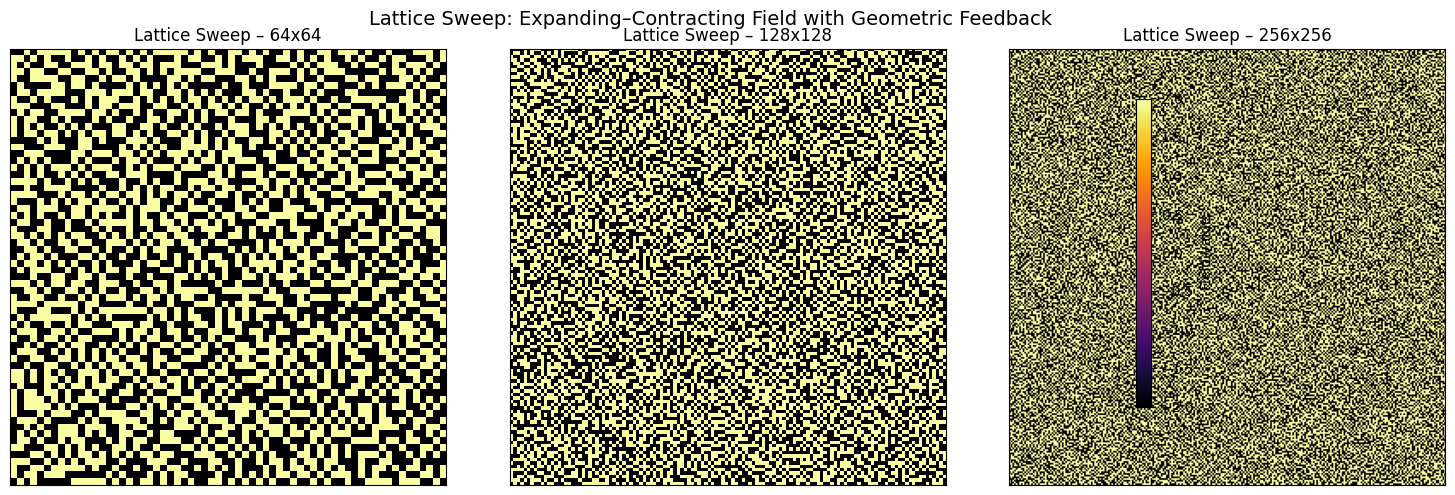

In [ ]:
# LATTICE SWEEP: expanding–contracting field with geometric feedback
# Resolutions: 64x64, 128x128, 256x256

import numpy as np
import matplotlib.pyplot as plt

# ---------------------------------------
# 1. Parameters
# ---------------------------------------
resolutions = [64, 128, 256]   # point densities
T = 2000                       # time steps
alpha0 = 0.02                  # expansion–contraction strength
beta = 0.5                     # curvature feedback strength
gamma = 1.0                    # nonlinear stabilization

# breathing frequency (how fast expansion/contraction oscillates)
omega = 2 * np.pi / 400        # one full cycle every 400 steps

# ---------------------------------------
# 2. Helper: Laplacian with periodic BCs
# ---------------------------------------
def laplacian_periodic(S, dx):
    """
    2D Laplacian with periodic boundary conditions.
    """
    # roll in x and y directions
    S_ip1 = np.roll(S, -1, axis=0)
    S_im1 = np.roll(S,  1, axis=0)
    S_jp1 = np.roll(S, -1, axis=1)
    S_jm1 = np.roll(S,  1, axis=1)

    lap = (S_ip1 + S_im1 + S_jp1 + S_jm1 - 4.0 * S) / (dx * dx)
    return lap

# ---------------------------------------
# 3. Run lattice sweep
# ---------------------------------------
fields_final = []

for NX in resolutions:
    NY = NX
    L = 1.0
    dx = L / NX

    # grid (not strictly needed for dynamics, but useful if you extend later)
    x = np.linspace(0, L, NX, endpoint=False)
    y = np.linspace(0, L, NY, endpoint=False)
    X, Y = np.meshgrid(x, y, indexing='ij')

    # initial uniform field + tiny noise
    S = np.ones((NX, NY), dtype=np.float64) * 0.1
    S += 1e-3 * np.random.randn(NX, NY)

    for t in range(T):
        # mean field
        S_mean = S.mean()

        # breathing coefficient: expansion + contraction
        alpha_t = alpha0 * np.sin(omega * t)

        # expansion–contraction term (relative to mean)
        # pushes field away from uniformity in a symmetric way
        expand_contract = alpha_t * (S - S_mean)

        # curvature feedback via Laplacian
        lap = laplacian_periodic(S, dx)
        curvature_term = beta * lap

        # nonlinear stabilization (prevents blow-up, encourages pockets)
        nonlinear_term = -gamma * (S**3)

        # update
        S = S + expand_contract + curvature_term + nonlinear_term

        # optional: mild clipping to keep values reasonable
        S = np.clip(S, -2.0, 2.0)

    fields_final.append(S)

# ---------------------------------------
# 4. Visualize lattice sweep
# ---------------------------------------
fig, axes = plt.subplots(1, len(resolutions), figsize=(5 * len(resolutions), 5))

vmin = min(S.min() for S in fields_final)
vmax = max(S.max() for S in fields_final)

for ax, NX, S in zip(axes, resolutions, fields_final):
    im = ax.imshow(S, cmap='inferno', origin='lower', vmin=vmin, vmax=vmax)
    ax.set_title(f"Lattice Sweep – {NX}x{NX}")
    ax.set_xticks([])
    ax.set_yticks([])

fig.colorbar(im, ax=axes.ravel().tolist(), shrink=0.8, label='Field value')
plt.suptitle("Lattice Sweep: Expanding–Contracting Field with Geometric Feedback", fontsize=14)
plt.tight_layout()
plt.show()


/tmp/ipykernel_897/3435607133.py:94: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


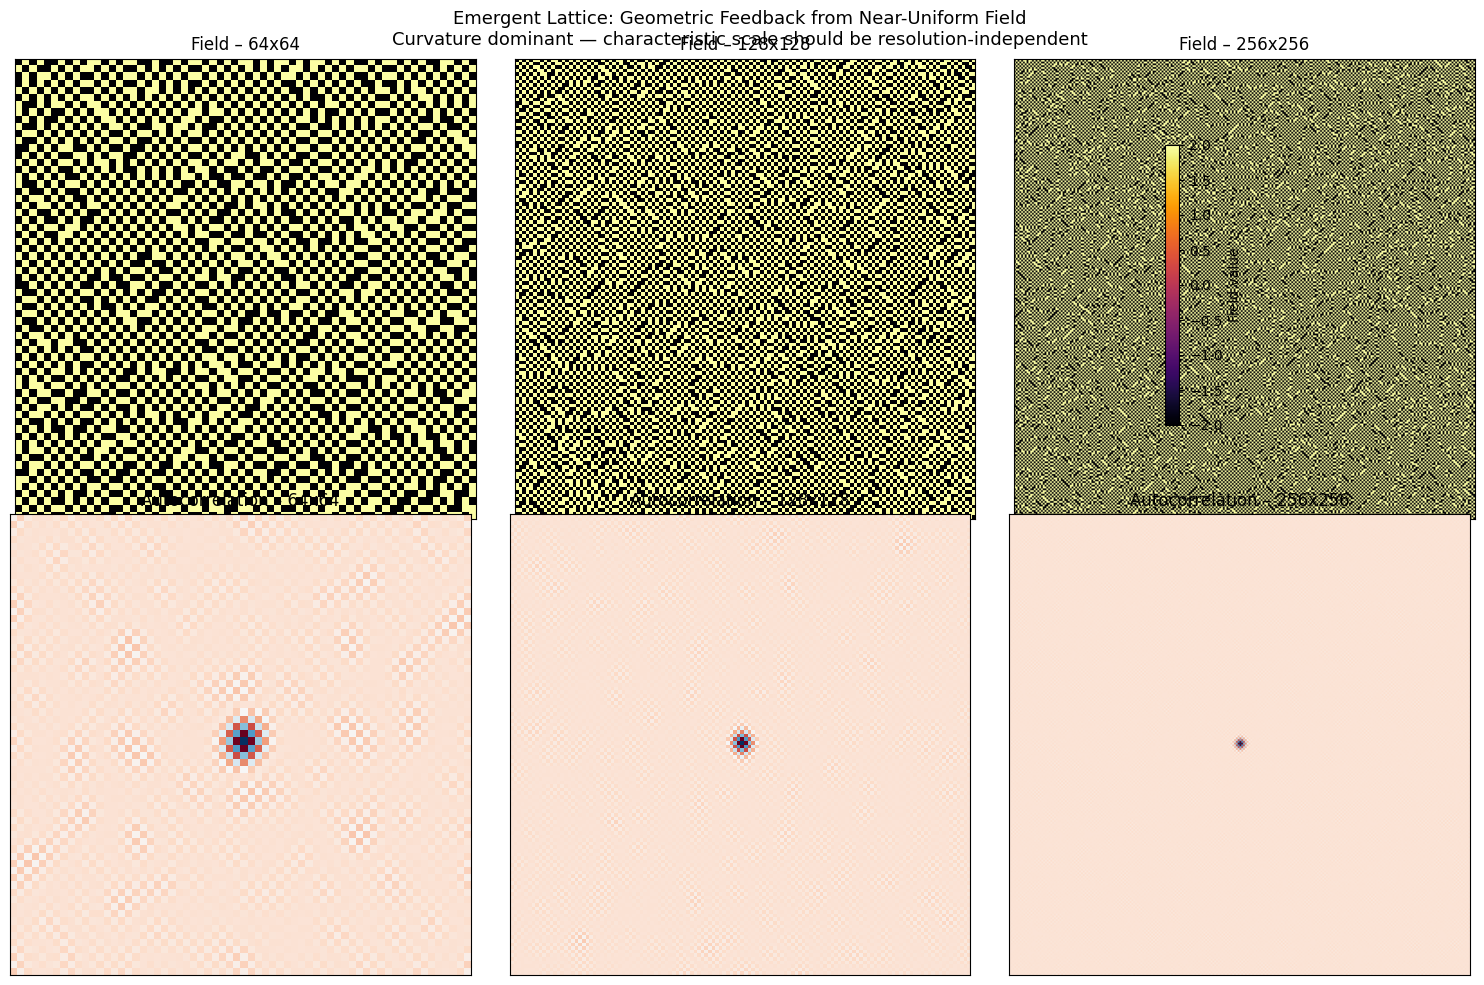


Characteristic scale check:
If emergent lattice is real, physical spacing should be ~constant

  64x64: first autocorr minimum at pixel 1 → physical spacing ≈ 0.016 L
  128x128: first autocorr minimum at pixel 1 → physical spacing ≈ 0.008 L
  256x256: first autocorr minimum at pixel 1 → physical spacing ≈ 0.004 L


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ---------------------------------------
# Parameters
# ---------------------------------------
resolutions = [64, 128, 256]
T = 3000                        # time steps
alpha0 = 0.05                   # expansion-contraction strength
beta = 0.8                      # curvature feedback (dominant term)
gamma = 0.001                   # nonlinear stabiliser (weak - must not dominate)
omega = 2 * np.pi / 400         # breathing frequency

# ---------------------------------------
# Laplacian with periodic BCs
# ---------------------------------------
def laplacian_periodic(S, dx):
    S_ip1 = np.roll(S, -1, axis=0)
    S_im1 = np.roll(S,  1, axis=0)
    S_jp1 = np.roll(S, -1, axis=1)
    S_jm1 = np.roll(S,  1, axis=1)
    return (S_ip1 + S_im1 + S_jp1 + S_jm1 - 4.0 * S) / (dx * dx)

# ---------------------------------------
# Run sweep
# ---------------------------------------
fields_final = []
characteristic_scales = []

for NX in resolutions:
    NY = NX
    L = 1.0
    dx = L / NX

    # Near-uniform start - tiny noise only
    S = np.ones((NX, NY)) * 0.1
    S += 1e-4 * np.random.randn(NX, NY)

    for t in range(T):
        S_mean = S.mean()
        alpha_t = alpha0 * np.sin(omega * t)

        # Expansion-contraction relative to mean
        expand_contract = alpha_t * (S - S_mean)

        # Curvature feedback - dominant term
        lap = laplacian_periodic(S, dx)
        curvature_term = beta * dx * dx * lap  # scaled to physical units

        # Weak stabiliser - prevents blowup only
        nonlinear_term = -gamma * (S**3)

        S = S + expand_contract + curvature_term + nonlinear_term
        S = np.clip(S, -2.0, 2.0)

    fields_final.append(S)

    # Measure characteristic scale via autocorrelation
    S_norm = S - S.mean()
    autocorr = np.fft.ifft2(np.abs(np.fft.fft2(S_norm))**2).real
    autocorr = np.roll(autocorr, NX//2, axis=0)
    autocorr = np.roll(autocorr, NY//2, axis=1)
    autocorr /= autocorr.max()
    characteristic_scales.append(autocorr)

# ---------------------------------------
# Visualise fields
# ---------------------------------------
fig, axes = plt.subplots(2, len(resolutions),
                          figsize=(5 * len(resolutions), 10))

vmin = min(S.min() for S in fields_final)
vmax = max(S.max() for S in fields_final)

for i, (ax, NX, S) in enumerate(zip(axes[0], resolutions, fields_final)):
    im = ax.imshow(S, cmap='inferno', origin='lower', vmin=vmin, vmax=vmax)
    ax.set_title(f"Field – {NX}x{NX}")
    ax.set_xticks([])
    ax.set_yticks([])

for i, (ax, NX, autocorr) in enumerate(zip(axes[1], resolutions,
                                             characteristic_scales)):
    ax.imshow(autocorr, cmap='RdBu', origin='lower')
    ax.set_title(f"Autocorrelation – {NX}x{NX}")
    ax.set_xticks([])
    ax.set_yticks([])

fig.colorbar(im, ax=axes[0].tolist(), shrink=0.8, label='Field value')
plt.suptitle(
    "Emergent Lattice: Geometric Feedback from Near-Uniform Field\n"
    "Curvature dominant — characteristic scale should be resolution-independent",
    fontsize=13
)
plt.tight_layout()
plt.show()

# ---------------------------------------
# Report characteristic scale in physical units
# ---------------------------------------
print("\nCharacteristic scale check:")
print("If emergent lattice is real, physical spacing should be ~constant\n")
for NX, autocorr in zip(resolutions, characteristic_scales):
    centre = NX // 2
    row = autocorr[centre, :]
    # find first minimum after centre - that's half the lattice spacing
    for k in range(centre+1, NX):
        if row[k] > row[k-1]:
            first_min_pixel = k - 1
            break
    physical_spacing = (first_min_pixel - centre) / NX
    print(f"  {NX}x{NX}: first autocorr minimum at pixel {first_min_pixel - centre}"
          f" → physical spacing ≈ {physical_spacing:.3f} L")


Ring points: 48


/tmp/ipykernel_897/1347534011.py:104: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


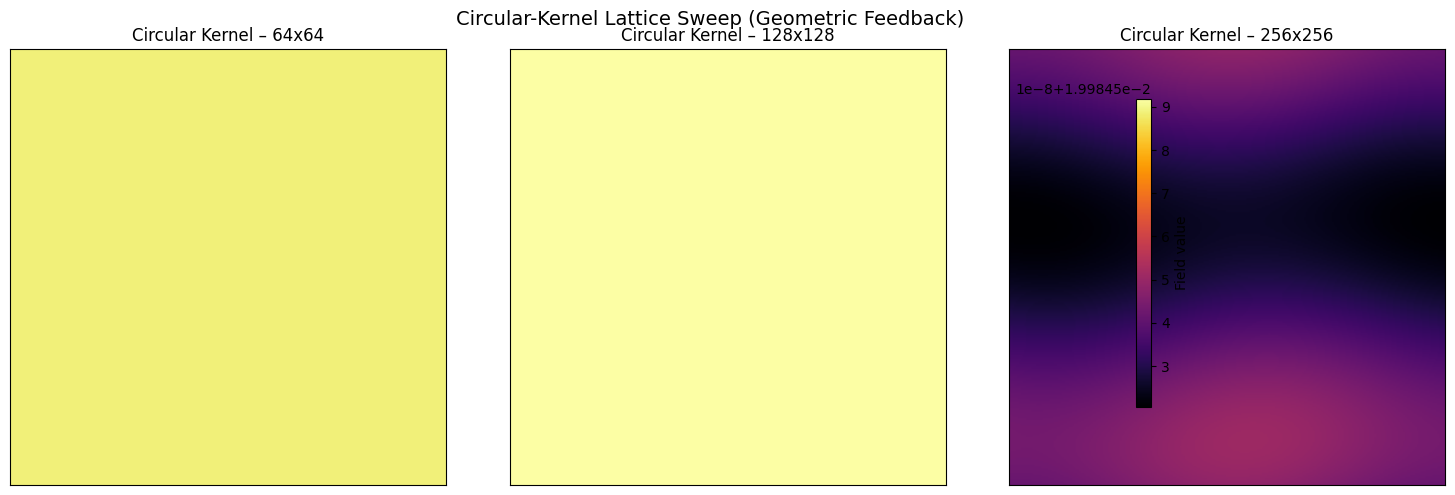

In [ ]:
# ============================================================
# CIRCULAR KERNEL LATTICE SWEEP
# Expanding–Contracting Field with Ring-Based Geometric Feedback
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

# ---------------------------------------
# 1. Parameters
# ---------------------------------------
resolutions = [64, 128, 256]     # point densities
T = 1500                         # time steps

R = 8                            # ring radius (in grid cells)
beta = 0.15                      # circular feedback strength
gamma = 0.8                      # nonlinear stabilization
alpha0 = 0.02                    # breathing amplitude
omega = 2 * np.pi / 300          # breathing frequency

# ---------------------------------------
# 2. Build ring offsets (approximate circle)
# ---------------------------------------
def ring_offsets(R):
    offsets = []
    for di in range(-R-2, R+3):
        for dj in range(-R-2, R+3):
            d = np.sqrt(di**2 + dj**2)
            if abs(d - R) < 0.5:   # near the ring
                offsets.append((di, dj))
    return offsets

ring = ring_offsets(R)
print(f"Ring points: {len(ring)}")

# ---------------------------------------
# 3. Circular feedback operator
# ---------------------------------------
def circular_feedback(S, ring):
    NX, NY = S.shape
    out = np.zeros_like(S)

    for i in range(NX):
        for j in range(NY):
            acc = 0.0
            for di, dj in ring:
                ii = (i + di) % NX
                jj = (j + dj) % NY
                acc += S[ii, jj]
            ring_avg = acc / len(ring)
            out[i, j] = ring_avg - S[i, j]

    return out

# ---------------------------------------
# 4. Run lattice sweep
# ---------------------------------------
fields_final = []

for NX in resolutions:
    NY = NX
    L = 1.0
    dx = L / NX

    # initial uniform field + tiny noise
    S = np.ones((NX, NY)) * 0.1
    S += 1e-3 * np.random.randn(NX, NY)

    for t in range(T):
        S_mean = S.mean()

        # breathing term
        alpha_t = alpha0 * np.sin(omega * t)
        expand_contract = alpha_t * (S - S_mean)

        # circular geometric feedback
        circ = beta * circular_feedback(S, ring)

        # nonlinear stabilization
        nonlinear = -gamma * (S**3)

        # update
        S = S + expand_contract + circ + nonlinear
        S = np.clip(S, -2.0, 2.0)

    fields_final.append(S)

# ---------------------------------------
# 5. Visualize lattice sweep
# ---------------------------------------
fig, axes = plt.subplots(1, len(resolutions), figsize=(5 * len(resolutions), 5))

vmin = min(S.min() for S in fields_final)
vmax = max(S.max() for S in fields_final)

for ax, NX, S in zip(axes, resolutions, fields_final):
    im = ax.imshow(S, cmap='inferno', origin='lower', vmin=vmin, vmax=vmax)
    ax.set_title(f"Circular Kernel – {NX}x{NX}")
    ax.set_xticks([])
    ax.set_yticks([])

fig.colorbar(im, ax=axes.ravel().tolist(), shrink=0.8, label='Field value')
plt.suptitle("Circular-Kernel Lattice Sweep (Geometric Feedback)", fontsize=14)
plt.tight_layout()
plt.show()
